In [186]:
#basics
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")


#preprocessing
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, PowerTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
import category_encoders as ce
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import QuantileTransformer, quantile_transform


#statistics
from scipy import stats
from scipy.stats import skew
from scipy.special import boxcox1p
from scipy.stats import randint

#feature engineering
from sklearn.feature_selection import mutual_info_regression


#transformers and pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn import set_config


#algorithms
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import ElasticNet, Lasso, Ridge
from sklearn.svm import SVR


#model evaluation
from sklearn.model_selection import GridSearchCV, cross_val_score, cross_validate
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import ShuffleSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, make_scorer
import optuna
from optuna.samplers import TPESampler
from optuna.visualization import plot_contour
from optuna.visualization import plot_edf
from optuna.visualization import plot_intermediate_values
from optuna.visualization import plot_optimization_history
from optuna.visualization import plot_parallel_coordinate
from optuna.visualization import plot_param_importances
from optuna.visualization import plot_slice


#stacking
from sklearn.ensemble import StackingRegressor
from mlxtend.regressor import StackingCVRegressor

In [187]:
# Read the data
original_train_df = pd.read_csv('data/train.csv', index_col='Id')
original_test_df = pd.read_csv('data/test.csv', index_col='Id')

# reserved for pipeline
pipe_data = original_train_df.copy()
pipe_test = original_test_df.copy()

# use for preliminary analysis
train_df = original_train_df.copy()
test_df = original_test_df.copy()
train_df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [188]:
#numerical feature descriptive statistics
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0
BsmtFinSF2,1460.0,46.549315,161.319273,0.0,0.00,0.0,0.00,1474.0


In [189]:
#categorical feature descriptive statistics
train_df.describe(include='object').T.sort_values(by=['unique'], ascending=False)

,count,unique,top,freq
Neighborhood,1460,25,NAmes,225
Exterior2nd,1460,16,VinylSd,504
Exterior1st,1460,15,VinylSd,515
SaleType,1460,9,WD,1267
Condition1,1460,9,Norm,1260
Condition2,1460,8,Norm,1445
HouseStyle,1460,8,1Story,726
RoofMatl,1460,8,CompShg,1434
Functional,1460,7,Typ,1360
BsmtFinType2,1422,6,Unf,1256


In [190]:
# 確認: 各セルごとに判定される
train_df != 0

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,True,True,True,True,True,True,True,True,True,True,...,False,True,True,True,False,True,True,True,True,True
2,True,True,True,True,True,True,True,True,True,True,...,False,True,True,True,False,True,True,True,True,True
3,True,True,True,True,True,True,True,True,True,True,...,False,True,True,True,False,True,True,True,True,True
4,True,True,True,True,True,True,True,True,True,True,...,False,True,True,True,False,True,True,True,True,True
5,True,True,True,True,True,True,True,True,True,True,...,False,True,True,True,False,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,True,True,True,True,True,True,True,True,True,True,...,False,True,True,True,False,True,True,True,True,True
1457,True,True,True,True,True,True,True,True,True,True,...,False,True,True,True,False,True,True,True,True,True
1458,True,True,True,True,True,True,True,True,True,True,...,False,True,True,True,True,True,True,True,True,True


In [191]:
# このままだとpandas series型となる
_series = train_df.isnull().sum().sort_values(ascending=False)
print(_series)
print(type(_series))

PoolQC         1453
MiscFeature    1406
Alley          1369
Fence          1179
MasVnrType      872
               ... 
Heating           0
HeatingQC         0
MSZoning          0
1stFlrSF          0
SalePrice         0
Length: 80, dtype: int64
<class 'pandas.core.series.Series'>


In [192]:
# データフレーム型に変換
_ms = pd.DataFrame(_series)
# カラム名を設定
_ms.columns = ["count"]
_ms

,count
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
...,...
Heating,0
HeatingQC,0
MSZoning,0
1stFlrSF,0


In [193]:
# 0のマスがtrueになる
_ms != 0

,count
PoolQC,True
MiscFeature,True
Alley,True
Fence,True
MasVnrType,True
...,...
Heating,False
HeatingQC,False
MSZoning,False
1stFlrSF,False


In [194]:
_ms_tf = (_ms != 0).any(axis=1)
print(_ms_tf)
print(type(_ms_tf))

PoolQC          True
MiscFeature     True
Alley           True
Fence           True
MasVnrType      True
               ...  
Heating        False
HeatingQC      False
MSZoning       False
1stFlrSF       False
SalePrice      False
Length: 80, dtype: bool
<class 'pandas.core.series.Series'>


In [195]:
# やっぱり上と同じ結果になる
_series_tf = (_series != 0)
print(_series_tf)
print(type(_series_tf))
# だがmissingというデータフレームから必要なものを一気に作りたいから、この方式は取られないのだろう


PoolQC          True
MiscFeature     True
Alley           True
Fence           True
MasVnrType      True
               ...  
Heating        False
HeatingQC      False
MSZoning       False
1stFlrSF       False
SalePrice      False
Length: 80, dtype: bool
<class 'pandas.core.series.Series'>


In [196]:
_ms_cutmiss = _ms.loc[_series_tf]
_ms_cutmiss

,count
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageYrBlt,81
GarageCond,81
GarageType,81


In [197]:
_ms_percent = _ms_cutmiss / len(train_df)
print(_ms_percent)

                 count
PoolQC        0.995205
MiscFeature   0.963014
Alley         0.937671
Fence         0.807534
MasVnrType    0.597260
FireplaceQu   0.472603
LotFrontage   0.177397
GarageYrBlt   0.055479
GarageCond    0.055479
GarageType    0.055479
GarageFinish  0.055479
GarageQual    0.055479
BsmtExposure  0.026027
BsmtFinType2  0.026027
BsmtCond      0.025342
BsmtQual      0.025342
BsmtFinType1  0.025342
MasVnrArea    0.005479
Electrical    0.000685


In [198]:
_ms_cutmiss["percent"] = _ms_percent
_ms_cutmiss

,count,percent
PoolQC,1453,0.995205
MiscFeature,1406,0.963014
Alley,1369,0.937671
Fence,1179,0.807534
MasVnrType,872,0.597260
FireplaceQu,690,0.472603
LotFrontage,259,0.177397
GarageYrBlt,81,0.055479
GarageCond,81,0.055479
GarageType,81,0.055479


In [199]:
_ms_cutmiss.style.background_gradient()

,count,percent
PoolQC,1453,0.995205
MiscFeature,1406,0.963014
Alley,1369,0.937671
Fence,1179,0.807534
MasVnrType,872,0.597260
FireplaceQu,690,0.472603
LotFrontage,259,0.177397
GarageYrBlt,81,0.055479
GarageCond,81,0.055479
GarageType,81,0.055479


In [200]:
# missing values
missing = pd.DataFrame(train_df.isnull().sum().sort_values(ascending=False))
missing.columns = ["count"]
missing = missing.loc[(missing!=0).any(axis=1)]
missing["percent"] = missing[0:] / 1460
missing.style.background_gradient('viridis')

,count,percent
PoolQC,1453,0.995205
MiscFeature,1406,0.963014
Alley,1369,0.937671
Fence,1179,0.807534
MasVnrType,872,0.597260
FireplaceQu,690,0.472603
LotFrontage,259,0.177397
GarageYrBlt,81,0.055479
GarageCond,81,0.055479
GarageType,81,0.055479


In [201]:
train_df.columns

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd',
       'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'Wo

In [202]:
#Group features for preprocessing purpose
categorical_features = [
    feature for feature in train_df.columns if
    train_df[feature].dtype == "object"
]
categorical_features

['MSZoning',
 'Street',
 'Alley',
 'LotShape',
 'LandContour',
 'Utilities',
 'LotConfig',
 'LandSlope',
 'Neighborhood',
 'Condition1',
 'Condition2',
 'BldgType',
 'HouseStyle',
 'RoofStyle',
 'RoofMatl',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrType',
 'ExterQual',
 'ExterCond',
 'Foundation',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'Heating',
 'HeatingQC',
 'CentralAir',
 'Electrical',
 'KitchenQual',
 'Functional',
 'FireplaceQu',
 'GarageType',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PavedDrive',
 'PoolQC',
 'Fence',
 'MiscFeature',
 'SaleType',
 'SaleCondition']

In [203]:
# 同じ結果
train_df.select_dtypes(include=["object"]).columns

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')

In [204]:
numerical_features = [
    feature for feature in train_df.columns
    if feature not in categorical_features + ['SalePrice']
]
numerical_features

['MSSubClass',
 'LotFrontage',
 'LotArea',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageYrBlt',
 'GarageCars',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal',
 'MoSold',
 'YrSold']

In [205]:
# axis=1: 列ごとに操作を適用
# any(axis=1): これは各列ごとにanyを評価するということ
# drop(axis=1): 指定カラムを列ごとに破壊する処理を適用する
train_df.select_dtypes("number").drop("SalePrice", axis=1).columns

Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold'],
      dtype='object')

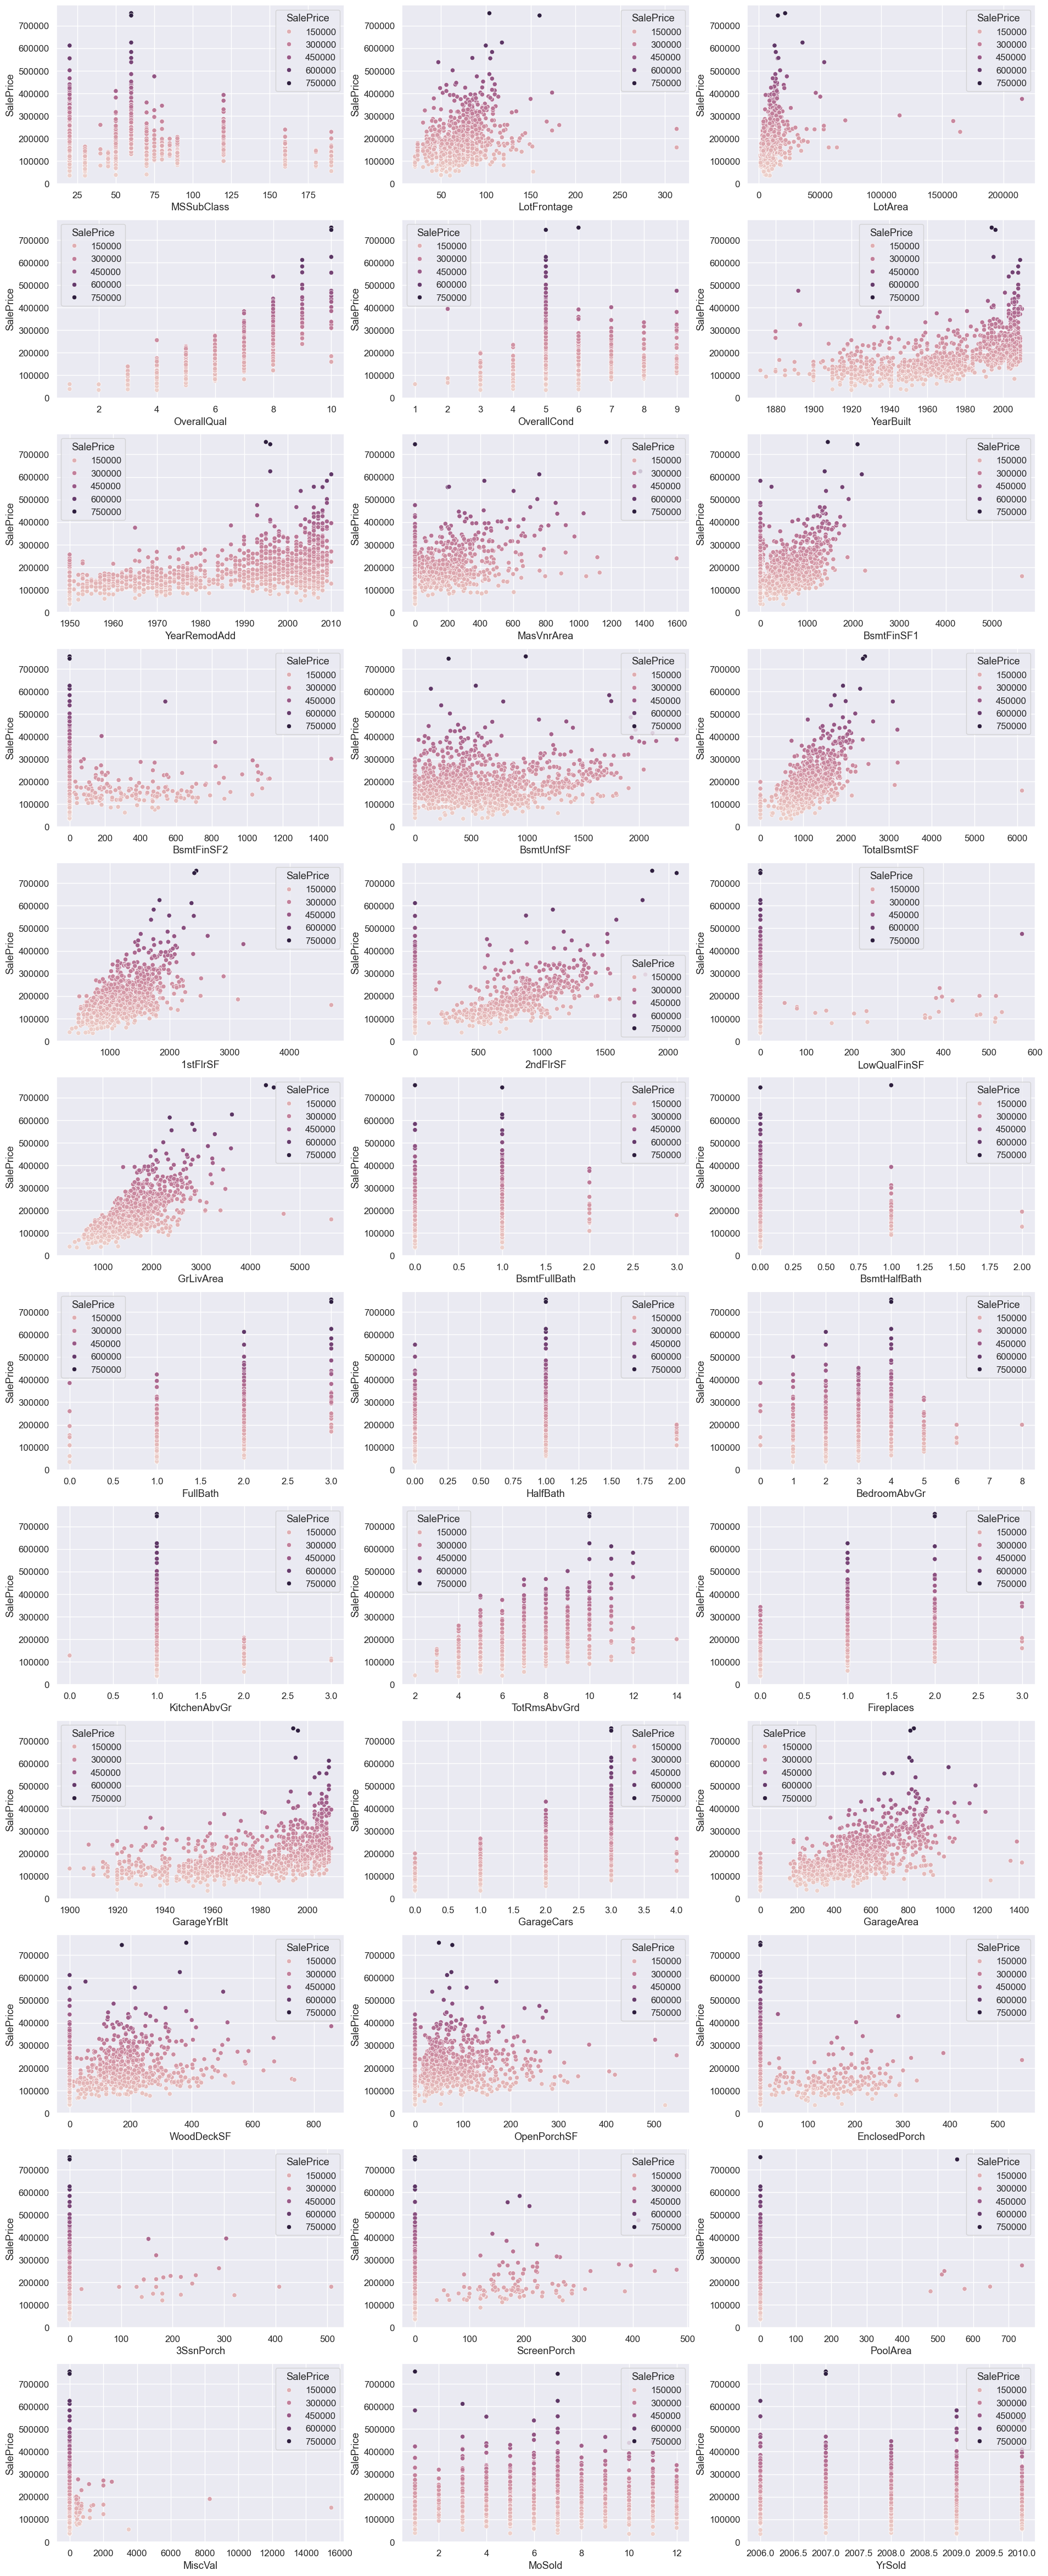

In [206]:
fig, ax = plt.subplots(12, 3, figsize=(23, 60))
for var, subplot in zip(numerical_features, ax.flatten()):
    sns.scatterplot(x=var, y='SalePrice',  data=train_df, ax=subplot, hue='SalePrice')

In [207]:
train_df = train_df.drop(train_df[(train_df['GrLivArea'] > 4000)
                                  & (train_df['SalePrice'] < 200000)].index)
train_df = train_df.drop(train_df[(train_df['GarageArea'] > 1200)
                                  & (train_df['SalePrice'] < 300000)].index)
train_df = train_df.drop(train_df[(train_df['TotalBsmtSF'] > 4000)
                                  & (train_df['SalePrice'] < 200000)].index)
train_df = train_df.drop(train_df[(train_df['1stFlrSF'] > 4000)
                                  & (train_df['SalePrice'] < 200000)].index)

train_df = train_df.drop(train_df[(train_df['TotRmsAbvGrd'] > 12)
                                  & (train_df['SalePrice'] < 230000)].index)
y = train_df.SalePrice

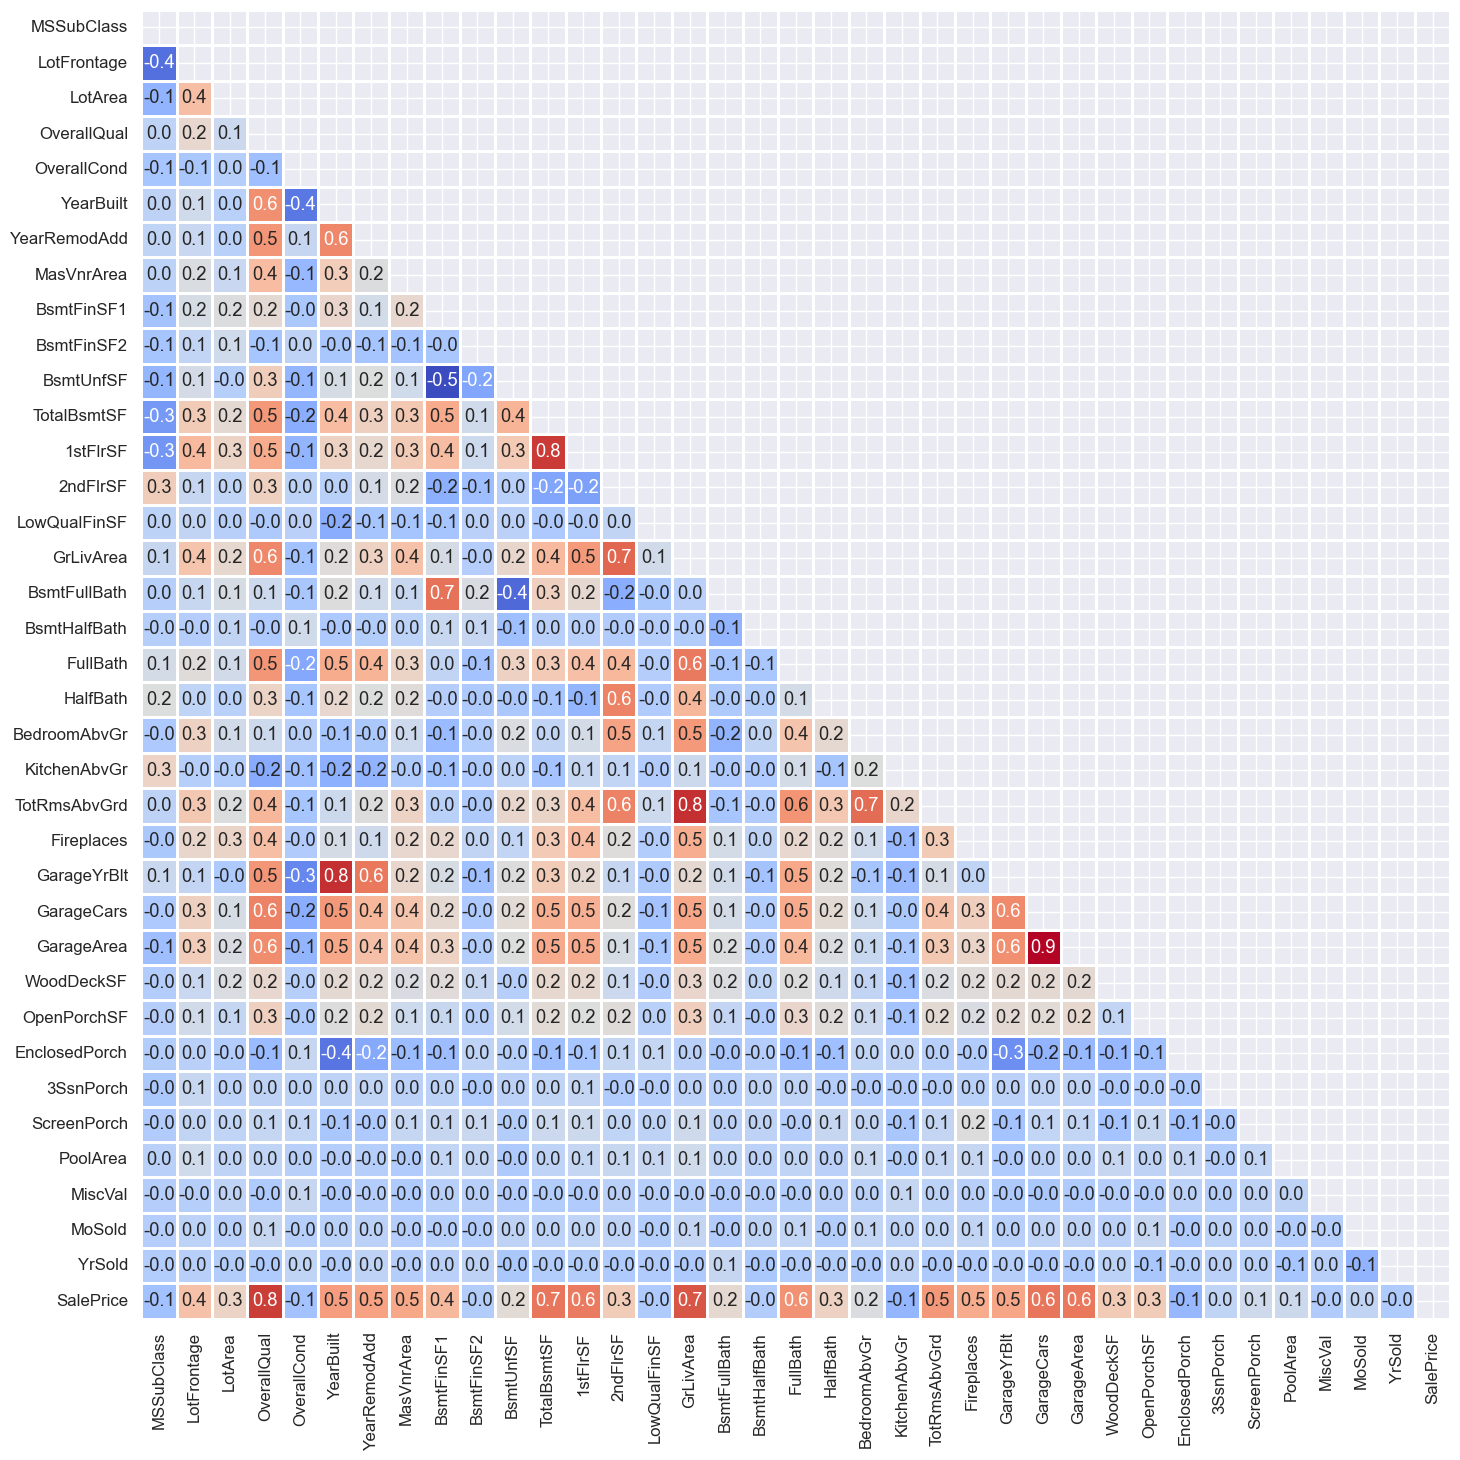

In [208]:
# Display correlations between numerical features and saleprice on heatmap.

sns.set(font_scale=1.1)
correlation_train = train_df.corr(numeric_only=True)
mask = np.triu(correlation_train)
plt.figure(figsize=(17, 17))
sns.heatmap(correlation_train,
            annot=True,
            fmt='.1f',
            cmap='coolwarm',
            square=True,
            mask=mask,
            linewidths=1,
            cbar=False);

In [209]:
numeric_df = train_df.select_dtypes(include=['float64', 'int64'])
correlation_train = numeric_df.corr()
correlation_train

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
MSSubClass,1.000000,-0.405173,-0.147834,0.036182,-0.060460,0.033102,0.040794,0.024089,-0.078862,-0.065151,...,-0.017963,-0.007069,-0.010899,-0.043747,-0.025300,0.008360,-0.006949,-0.007689,-0.018283,-0.085132
LotFrontage,-0.405173,1.000000,0.387586,0.239170,-0.053104,0.117347,0.083815,0.164175,0.150102,0.056149,...,0.083714,0.117743,0.016189,0.075008,0.047071,0.116790,-0.000006,0.024059,0.006441,0.373281
LotArea,-0.147834,0.387586,1.000000,0.095179,0.000235,0.008516,0.008950,0.084496,0.174111,0.115183,...,0.165787,0.063188,-0.015730,0.021666,0.045989,0.036706,0.038765,0.007268,-0.012983,0.269691
OverallQual,0.036182,0.239170,0.095179,1.000000,-0.094046,0.571036,0.548267,0.403265,0.224685,-0.059007,...,0.240680,0.296392,-0.114168,0.030894,0.066060,0.044794,-0.029751,0.071878,-0.027983,0.796033
OverallCond,-0.060460,-0.053104,0.000235,-0.094046,1.000000,-0.376594,0.072760,-0.126412,-0.042505,0.039708,...,-0.000339,-0.031583,0.069762,0.025312,0.054362,0.002235,0.069868,-0.003037,0.044302,-0.079445
YearBuilt,0.033102,0.117347,0.008516,0.571036,-0.376594,1.000000,0.592568,0.311643,0.250668,-0.049241,...,0.224598,0.184882,-0.388595,0.031472,-0.050504,-0.005280,-0.033566,0.011119,-0.014864,0.523727
YearRemodAdd,0.040794,0.083815,0.008950,0.548267,0.072760,0.592568,1.000000,0.174777,0.123777,-0.067593,...,0.206467,0.221739,-0.194021,0.045538,-0.038519,-0.003454,-0.008901,0.022318,0.035673,0.506644
MasVnrArea,0.024089,0.164175,0.084496,0.403265,-0.126412,0.311643,0.174777,1.000000,0.239677,-0.071532,...,0.156646,0.104785,-0.109455,0.019619,0.063573,-0.020573,-0.029221,-0.004756,-0.007882,0.482382
BsmtFinSF1,-0.078862,0.150102,0.174111,0.224685,-0.042505,0.250668,0.123777,0.239677,1.000000,-0.049870,...,0.201577,0.074175,-0.104245,0.029165,0.068367,0.053038,0.005490,-0.002376,0.017044,0.410453
BsmtFinSF2,-0.065151,0.056149,0.115183,-0.059007,0.039708,-0.049241,-0.067593,-0.071532,-0.049870,1.000000,...,0.068638,0.005085,0.036131,-0.030138,0.088578,0.046305,0.005062,-0.015627,0.031599,-0.011486


In [210]:
np.triu(correlation_train)

array([[ 1.        , -0.40517293, -0.14783359, ..., -0.00768894,
        -0.01828288, -0.08513203],
       [ 0.        ,  1.        ,  0.3875858 , ...,  0.02405856,
         0.00644114,  0.37328106],
       [ 0.        ,  0.        ,  1.        , ...,  0.00726844,
        -0.01298319,  0.2696909 ],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  1.        ,
        -0.14701403,  0.04643685],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         1.        , -0.02932751],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  1.        ]])

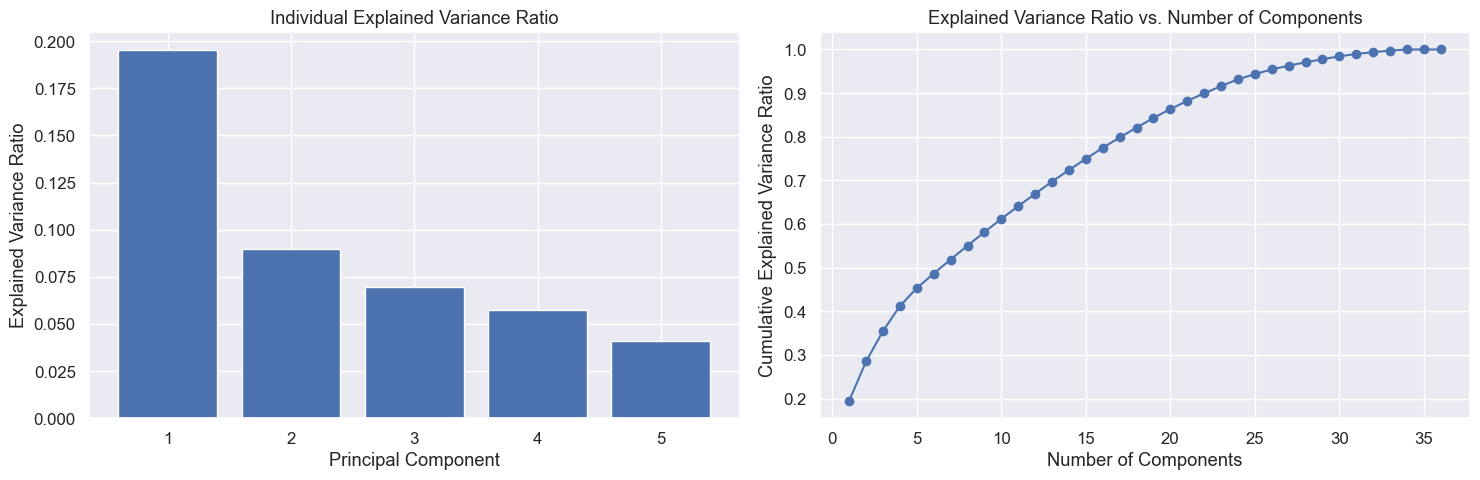

各主成分の寄与率:
PC1: 0.195 (19.5%)
PC2: 0.090 (9.0%)
PC3: 0.070 (7.0%)
PC4: 0.057 (5.7%)
PC5: 0.041 (4.1%)

Top features in first three principal components:

PC1:
OverallQual    0.306073
GrLivArea      0.298020
GarageCars     0.292713
GarageArea     0.283663
FullBath       0.267884
Name: 0, dtype: float64

PC2:
2ndFlrSF        0.431586
BedroomAbvGr    0.354928
TotRmsAbvGrd    0.323780
GrLivArea       0.261773
HalfBath        0.226991
Name: 1, dtype: float64

PC3:
GarageYrBlt     0.352334
YearBuilt       0.315642
MSSubClass      0.271535
YearRemodAdd    0.260522
HalfBath        0.159041
Name: 2, dtype: float64


In [211]:
# 主成分分析

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. 数値データの準備
numeric_df = train_df.select_dtypes(include=['float64', 'int64'])
# SalePriceは除外
X = numeric_df.drop('SalePrice', axis=1)

# 2. 欠損値の処理
# 簡単のため平均値で補完
X = X.fillna(X.mean())

# 3. データの標準化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. PCAの実行
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# 5. 寄与率の可視化
plt.figure(figsize=(15, 5))

# 個別の寄与率
plt.subplot(1, 2, 1)
plt.bar(range(1, 6), pca.explained_variance_ratio_[:5])
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Individual Explained Variance Ratio')

# 累積寄与率
plt.subplot(1, 2, 2)
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1),
         np.cumsum(pca.explained_variance_ratio_), 'bo-')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.title('Explained Variance Ratio vs. Number of Components')
plt.grid(True)

plt.tight_layout()
plt.show()

# 6. 寄与率の数値確認
print("各主成分の寄与率:")
for i, ratio in enumerate(pca.explained_variance_ratio_[:5], 1):
    print(f"PC{i}: {ratio:.3f} ({ratio*100:.1f}%)")

# print("\n累積寄与率:")
# cumulative = np.cumsum(pca.explained_variance_ratio_)
# for i, cum_ratio in enumerate(cumulative[:5], 1):
#     print(f"PC{i}まで: {cum_ratio:.3f} ({cum_ratio*100:.1f}%)")

# 7. 主成分の寄与度を確認
component_df = pd.DataFrame(
    pca.components_,
    columns=X.columns
)
print("\nTop features in first three principal components:")
print("\nPC1:")
print(component_df.iloc[0].sort_values(ascending=False)[:5])
print("\nPC2:")
print(component_df.iloc[1].sort_values(ascending=False)[:5])
print("\nPC3:")
print(component_df.iloc[2].sort_values(ascending=False)[:5])

In [212]:
_mutual_df = train_df[numerical_features]
print(_mutual_df.shape)
print(y.shape)

(1454, 36)
(1454,)


In [213]:
_mutual_info = mutual_info_regression(_mutual_df.fillna(0), y, random_state=1)
_mutual_info

array([0.28806321, 0.21795866, 0.16274017, 0.57525888, 0.11834877,
       0.36585246, 0.25334659, 0.09618247, 0.15795849, 0.        ,
       0.12161099, 0.37371869, 0.31204684, 0.19644801, 0.01616557,
       0.48985421, 0.02482958, 0.00973821, 0.2455146 , 0.08558719,
       0.06353968, 0.00768652, 0.21256219, 0.17196581, 0.26418983,
       0.37811444, 0.37310976, 0.10826905, 0.15726881, 0.02575686,
       0.        , 0.01671998, 0.        , 0.        , 0.        ,
       0.        ])

In [214]:
_mutual_df.columns

Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold'],
      dtype='object')

In [215]:
# determine the mutual information for numerical features
#You need to fillna to get results from mutual_info_regression function
mutual_df = train_df[numerical_features]

mutual_info = mutual_info_regression(mutual_df.fillna(0), y, random_state=1)

mutual_info = pd.Series(mutual_info)
mutual_info.index = mutual_df.columns
pd.DataFrame(mutual_info.sort_values(ascending=False), columns = ["Numerical_Feature_MI"] ).style.background_gradient("cool")

,Numerical_Feature_MI
OverallQual,0.575259
GrLivArea,0.489854
GarageCars,0.378114
TotalBsmtSF,0.373719
GarageArea,0.373110
YearBuilt,0.365852
1stFlrSF,0.312047
MSSubClass,0.288063
GarageYrBlt,0.264190
YearRemodAdd,0.253347


In [216]:
_mu_df_ctg = train_df[categorical_features]
_mu_df_ctg.head()

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
Id,,,,,,,,,,,,,,,,,,,,,
1,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
2,RL,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
3,RL,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
4,RL,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,...,Detchd,Unf,TA,TA,Y,NaN,NaN,NaN,WD,Abnorml
5,RL,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal


In [217]:
# for colname in _mu_df_ctg:
#     print(colname)
_mu_df_ctg['MSZoning'].factorize()

(array([0, 0, 0, ..., 0, 0, 0]),
 Index(['RL', 'RM', 'C (all)', 'FV', 'RH'], dtype='object'))

In [218]:
mutual_df_categorical = train_df[categorical_features]
#categorical features must be encoded to get mutual information
for colname in mutual_df_categorical:
    mutual_df_categorical[colname], _ = mutual_df_categorical[colname].factorize()
mutual_info = mutual_info_regression(mutual_df_categorical.fillna("Do_not_have_feature"), y, random_state=1)

mutual_info = pd.Series(mutual_info)
mutual_info.index = mutual_df_categorical.columns
pd.DataFrame(mutual_info.sort_values(ascending=False), columns = ["Categorical_Feature_MI"] ).style.background_gradient("cool")

,Categorical_Feature_MI
Neighborhood,0.504944
KitchenQual,0.347321
ExterQual,0.335577
BsmtQual,0.326011
GarageFinish,0.260566
GarageType,0.210301
FireplaceQu,0.205768
Foundation,0.200220
HeatingQC,0.166743
Exterior2nd,0.163150


In [219]:
categorical_champions = ["ExterQual", "BsmtQual", "KitchenQual", "GarageFinish", "GarageType","Foundation"]    



# fig, ax = plt.subplots(3, 2, figsize=(22, 18))
# for var, subplot in zip(categorical_champions, ax.flatten()):    
#     sns.swarmplot(x=var, y='SalePrice', data=train_df, ax=subplot, palette='Set3')
#     for ax in fig.axes:
#         plt.sca(ax)
#         plt.xticks(rotation=60)

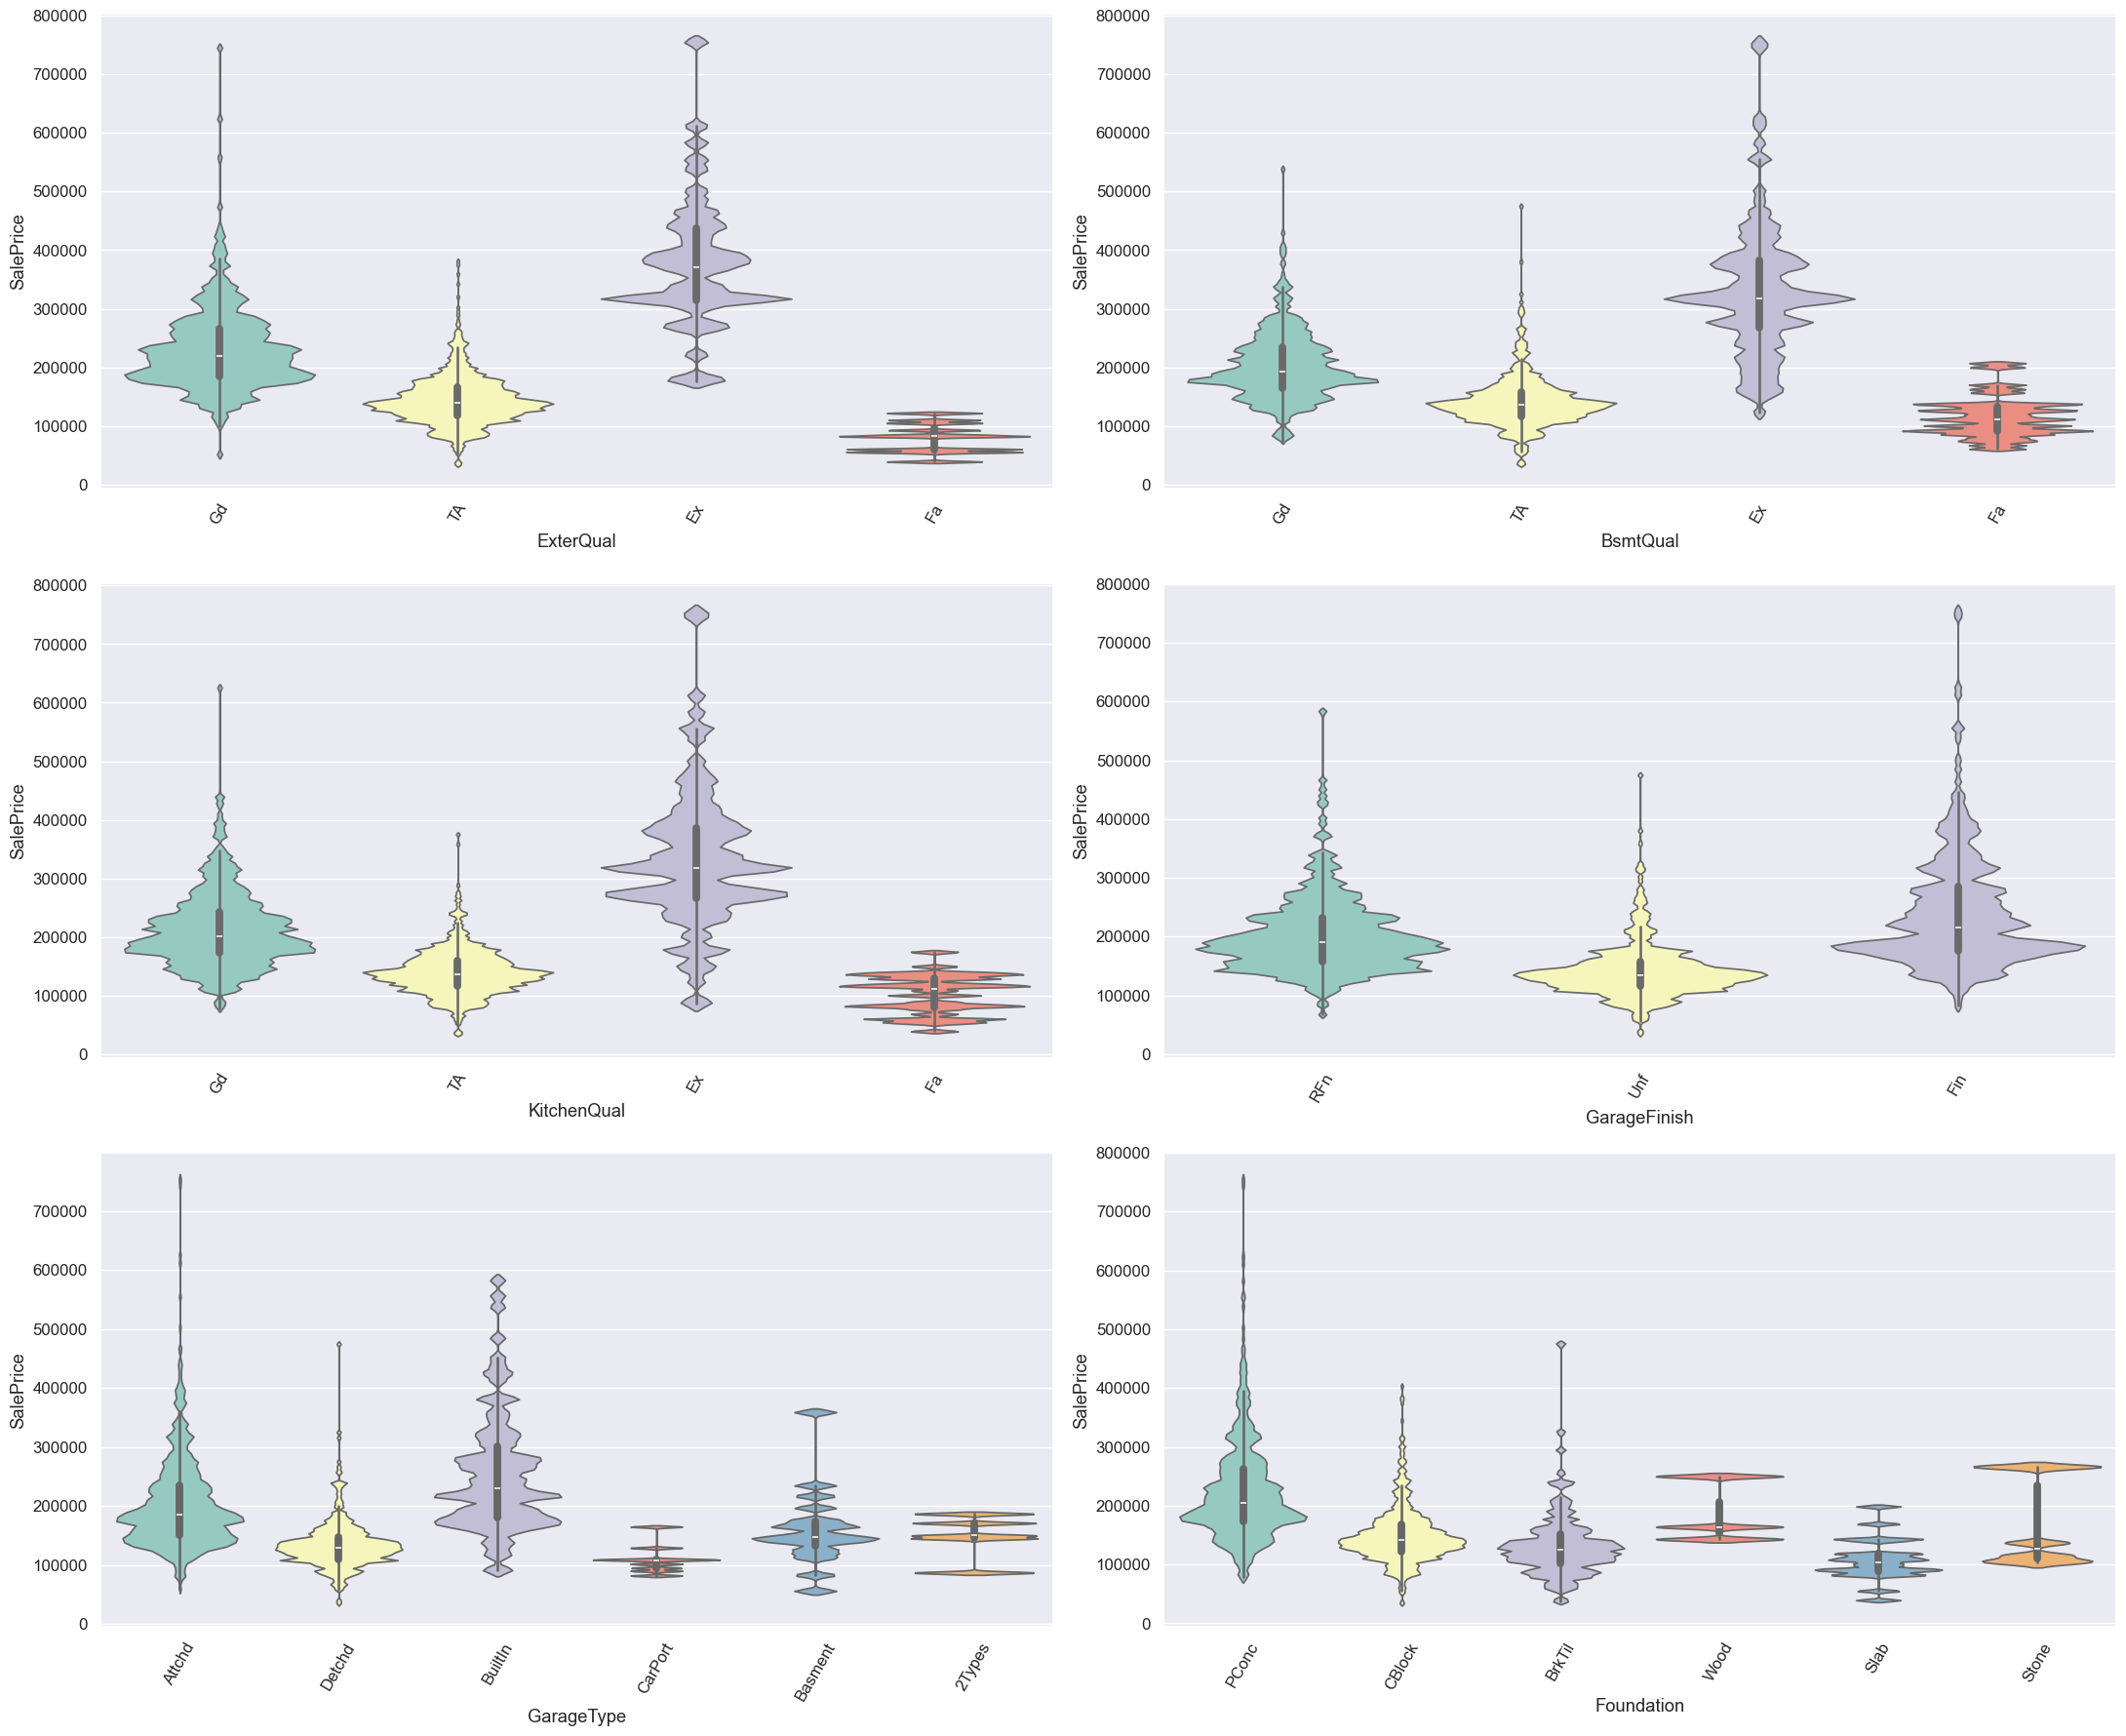

In [220]:
categorical_champions = ["ExterQual", "BsmtQual", "KitchenQual", "GarageFinish", "GarageType", "Foundation"]    

fig, ax = plt.subplots(3, 2, figsize=(22, 18))
for var, subplot in zip(categorical_champions, ax.flatten()):    
    # swarmplotをviolinplotに変更
    sns.violinplot(
        x=var, 
        y='SalePrice', 
        data=train_df, 
        bw=0.05,
        ax=subplot, 
        palette='Set3',
        # オプション: 内部にboxplotを表示
        inner='box'  
    )
    for ax in fig.axes:
        plt.sca(ax)
        plt.xticks(rotation=60)

plt.tight_layout()  # サブプロット間の間隔を自動調整

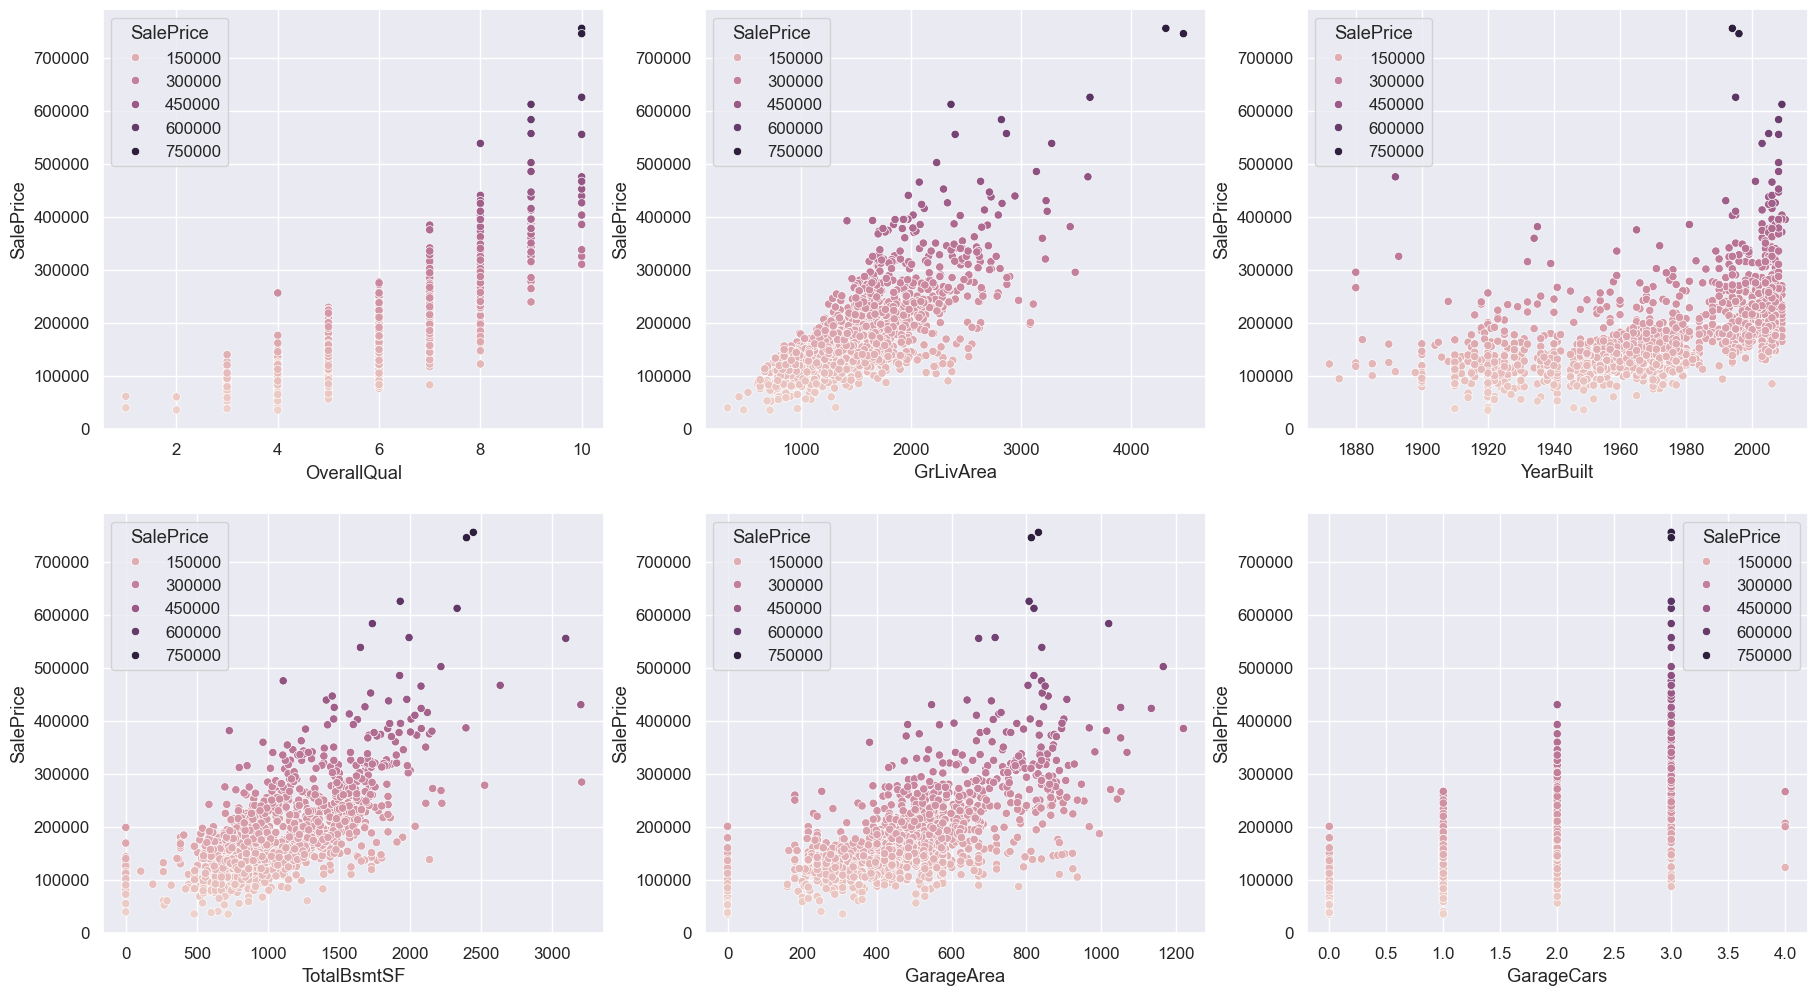

In [221]:
numerical_champions = ["OverallQual", "GrLivArea", "YearBuilt",  "TotalBsmtSF","GarageArea", "GarageCars"]

fig, ax = plt.subplots(2, 3, figsize=(22, 12))
for var, subplot in zip(numerical_champions, ax.flatten()):
    sns.scatterplot(x=var, y='SalePrice',  data=train_df, ax=subplot, hue = 'SalePrice')
    

In [222]:
train_df["Lack_of_feature_index"] = train_df[["Street", "Alley", "MasVnrType", "GarageType", "MiscFeature",  'BsmtQual',
                                              'FireplaceQu','PoolQC','Fence']].isnull().sum(axis=1) + (train_df["MasVnrType"] == 'None')+ (train_df["CentralAir"] == 'No')
train_df ["MiscFeatureExtended"] = (train_df["PoolQC"].notnull()*1 + train_df["MiscFeature"].notnull()*1+ train_df["Fence"].notnull()*1).astype('int64')
train_df["Has_Alley"] = train_df["Alley"].notnull().astype('int64')
train_df["Lot_occupation"] = train_df["GrLivArea"]  / train_df["LotArea"]
train_df["Number_of_floors"] = (train_df["TotalBsmtSF"] != 0).astype('int64') + (train_df["1stFlrSF"] != 0).astype('int64') + (train_df["2ndFlrSF"] != 0).astype('int64')
train_df['Total_Close_Live_Area'] = train_df['GrLivArea'] + train_df['TotalBsmtSF'] 
train_df['Outside_live_area'] =  train_df['WoodDeckSF'] + train_df['OpenPorchSF'] + train_df['EnclosedPorch']+ train_df['3SsnPorch'] + train_df['ScreenPorch']
train_df['Total_usable_area'] = train_df['Total_Close_Live_Area'] + train_df['Outside_live_area']
train_df['Area_Quality_Indicator'] = train_df['Total_usable_area'] * train_df['OverallQual']
train_df['Area_Qual_Cond_Indicator'] = train_df['Total_usable_area'] * train_df['OverallQual']* train_df['OverallCond']
train_df['TotalBath'] = (train_df['FullBath'] + (0.5 * train_df['HalfBath']) + train_df['BsmtFullBath'] + (0.5 * train_df['BsmtHalfBath']))
train_df["Has_garage"] = train_df["GarageYrBlt"].notnull().astype('int64')
train_df['House_Age'] = train_df['YrSold'] - train_df['YearBuilt']
train_df["Is_Remodeled"] = (train_df["YearBuilt"] != train_df["YearRemodAdd"]).astype('int64')
train_df['HasBsmt'] = train_df['BsmtQual'].notnull().astype('int64')
train_df['Quality_conditition'] = train_df['OverallQual']* train_df['OverallCond']
train_df['Quality_conditition_2'] = train_df['OverallQual'] + train_df['OverallCond']
train_df['House_Age2'] = train_df['YrSold'] - train_df['YearRemodAdd']


new_features = list(set(train_df.columns) - set(categorical_features+numerical_features+['SalePrice']))
new_continuous_features= ["Lot_occupation", 'Total_Close_Live_Area', 'Outside_live_area', 'Total_usable_area','Area_Quality_Indicator', 'House_Age',  'Area_Qual_Cond_Indicator', 'Quality_conditition', 'House_Age2']
new_discrete_features = ["Lack_of_feature_index", "MiscFeatureExtended", "Has_Alley", "Number_of_floors", "Has_garage", "Is_Remodeled", 'TotalBath', 'HasBsmt', 'Quality_conditition_2'] 

assert new_features.sort() == (new_discrete_features + new_continuous_features).sort()

In [223]:
mutual_df = train_df[new_features]

mutual_info = mutual_info_regression(mutual_df.fillna(0), y, random_state=1)

mutual_info = pd.Series(mutual_info)
mutual_info.index = mutual_df.columns
pd.DataFrame(mutual_info.sort_values(ascending=False), columns = ["New_Feature_MI"] ).style.background_gradient("cool")

,New_Feature_MI
Area_Quality_Indicator,0.935381
Area_Qual_Cond_Indicator,0.740554
Total_Close_Live_Area,0.670074
Total_usable_area,0.643080
Quality_conditition,0.438180
Quality_conditition_2,0.352191
TotalBath,0.348697
House_Age,0.342057
House_Age2,0.263028
Lack_of_feature_index,0.152748


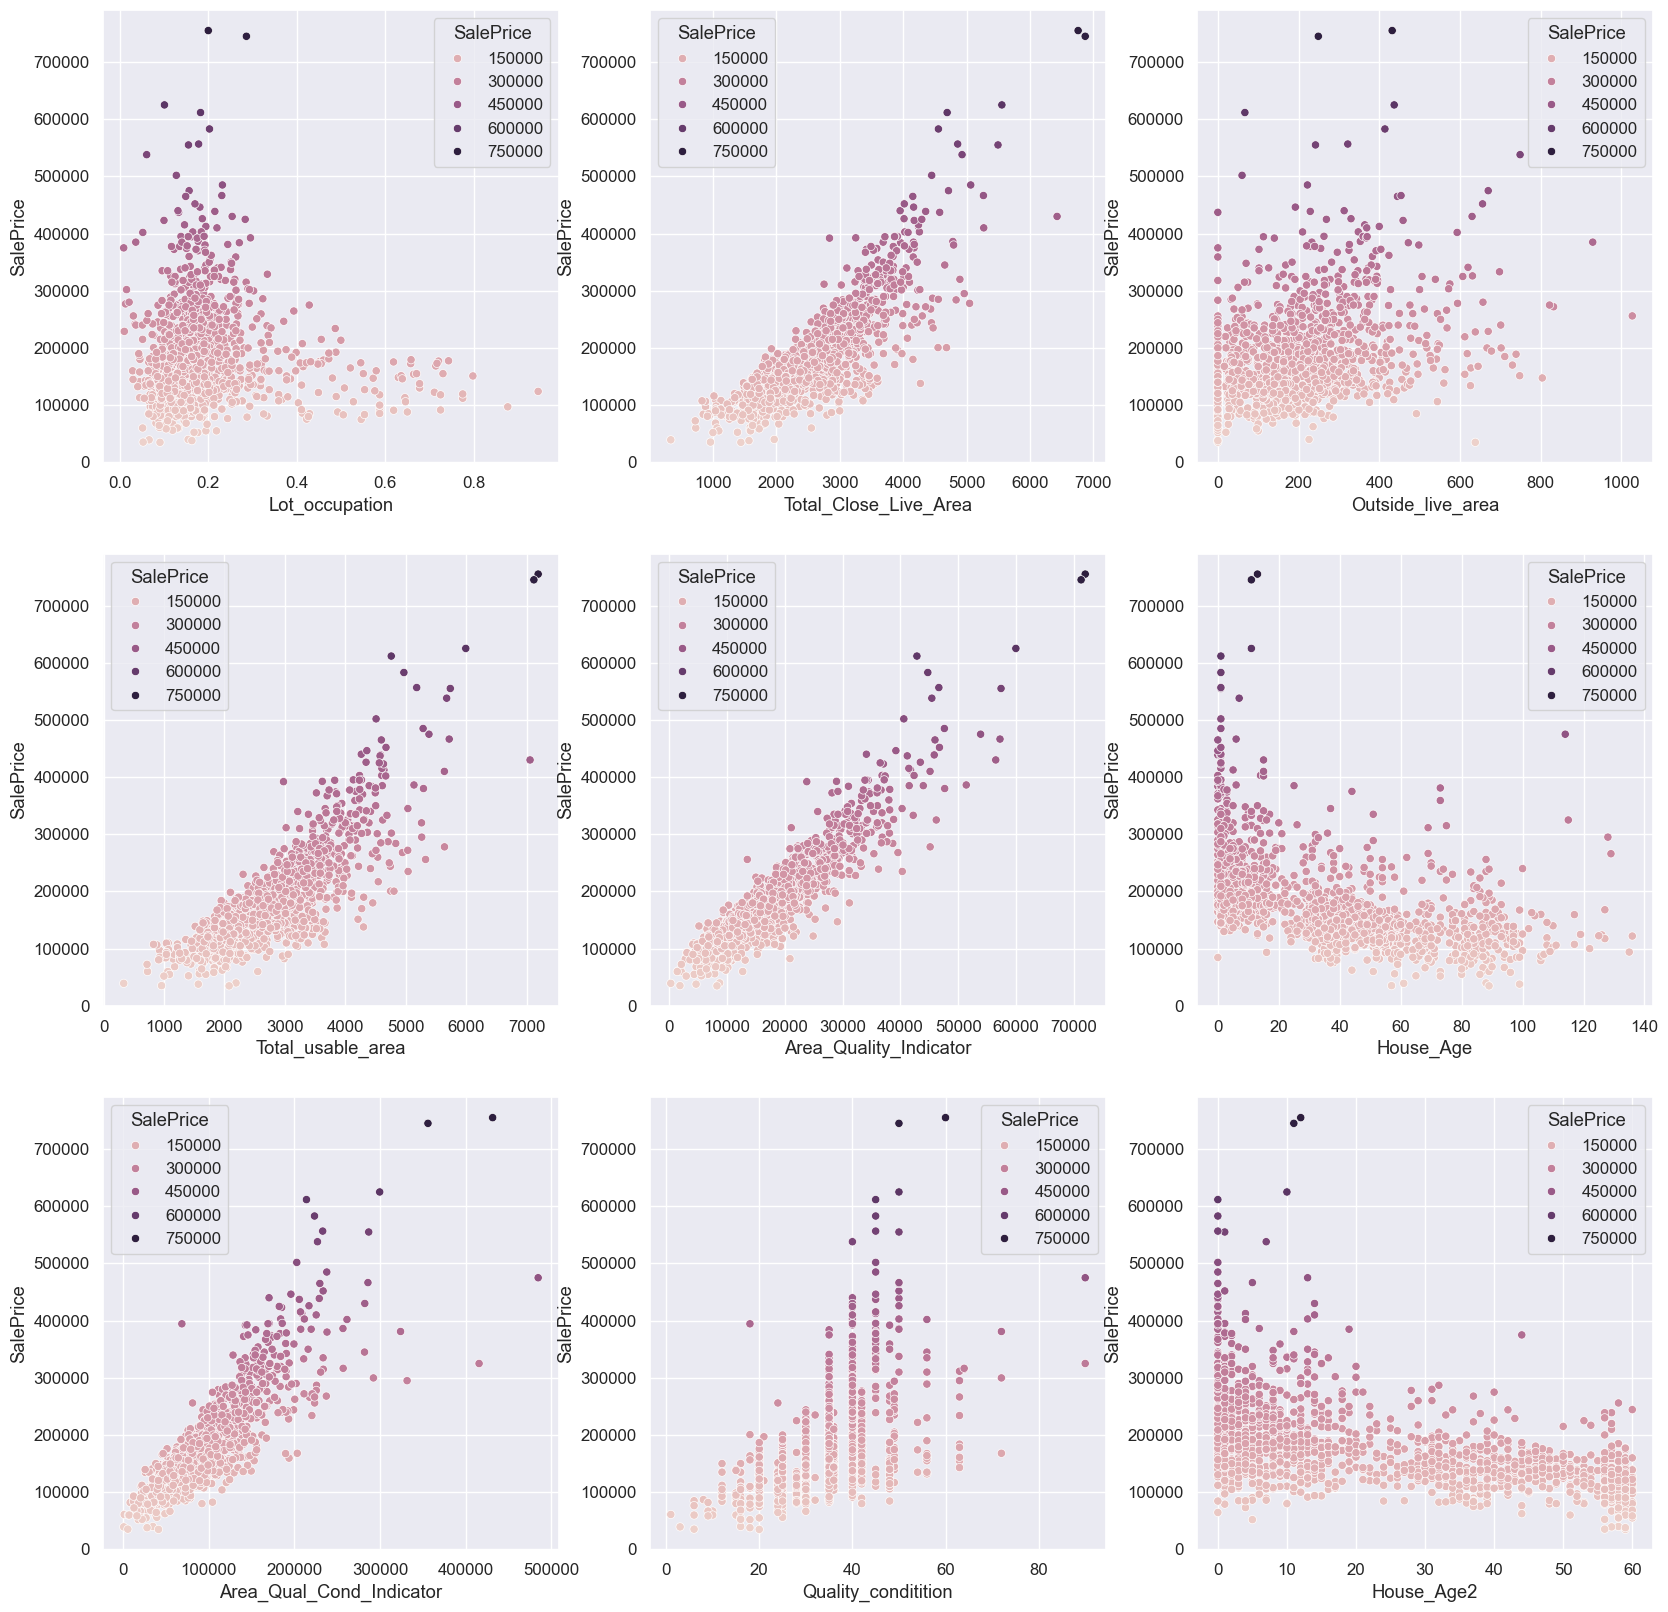

In [224]:
fig, ax = plt.subplots(3, 3, figsize=(20, 20))
for var, subplot in zip(new_continuous_features, ax.flatten()):
    sns.scatterplot(x=var, y='SalePrice',  data=train_df, ax=subplot, hue = 'SalePrice')

In [225]:
new_discrete_features

['Lack_of_feature_index',
 'MiscFeatureExtended',
 'Has_Alley',
 'Number_of_floors',
 'Has_garage',
 'Is_Remodeled',
 'TotalBath',
 'HasBsmt',
 'Quality_conditition_2']

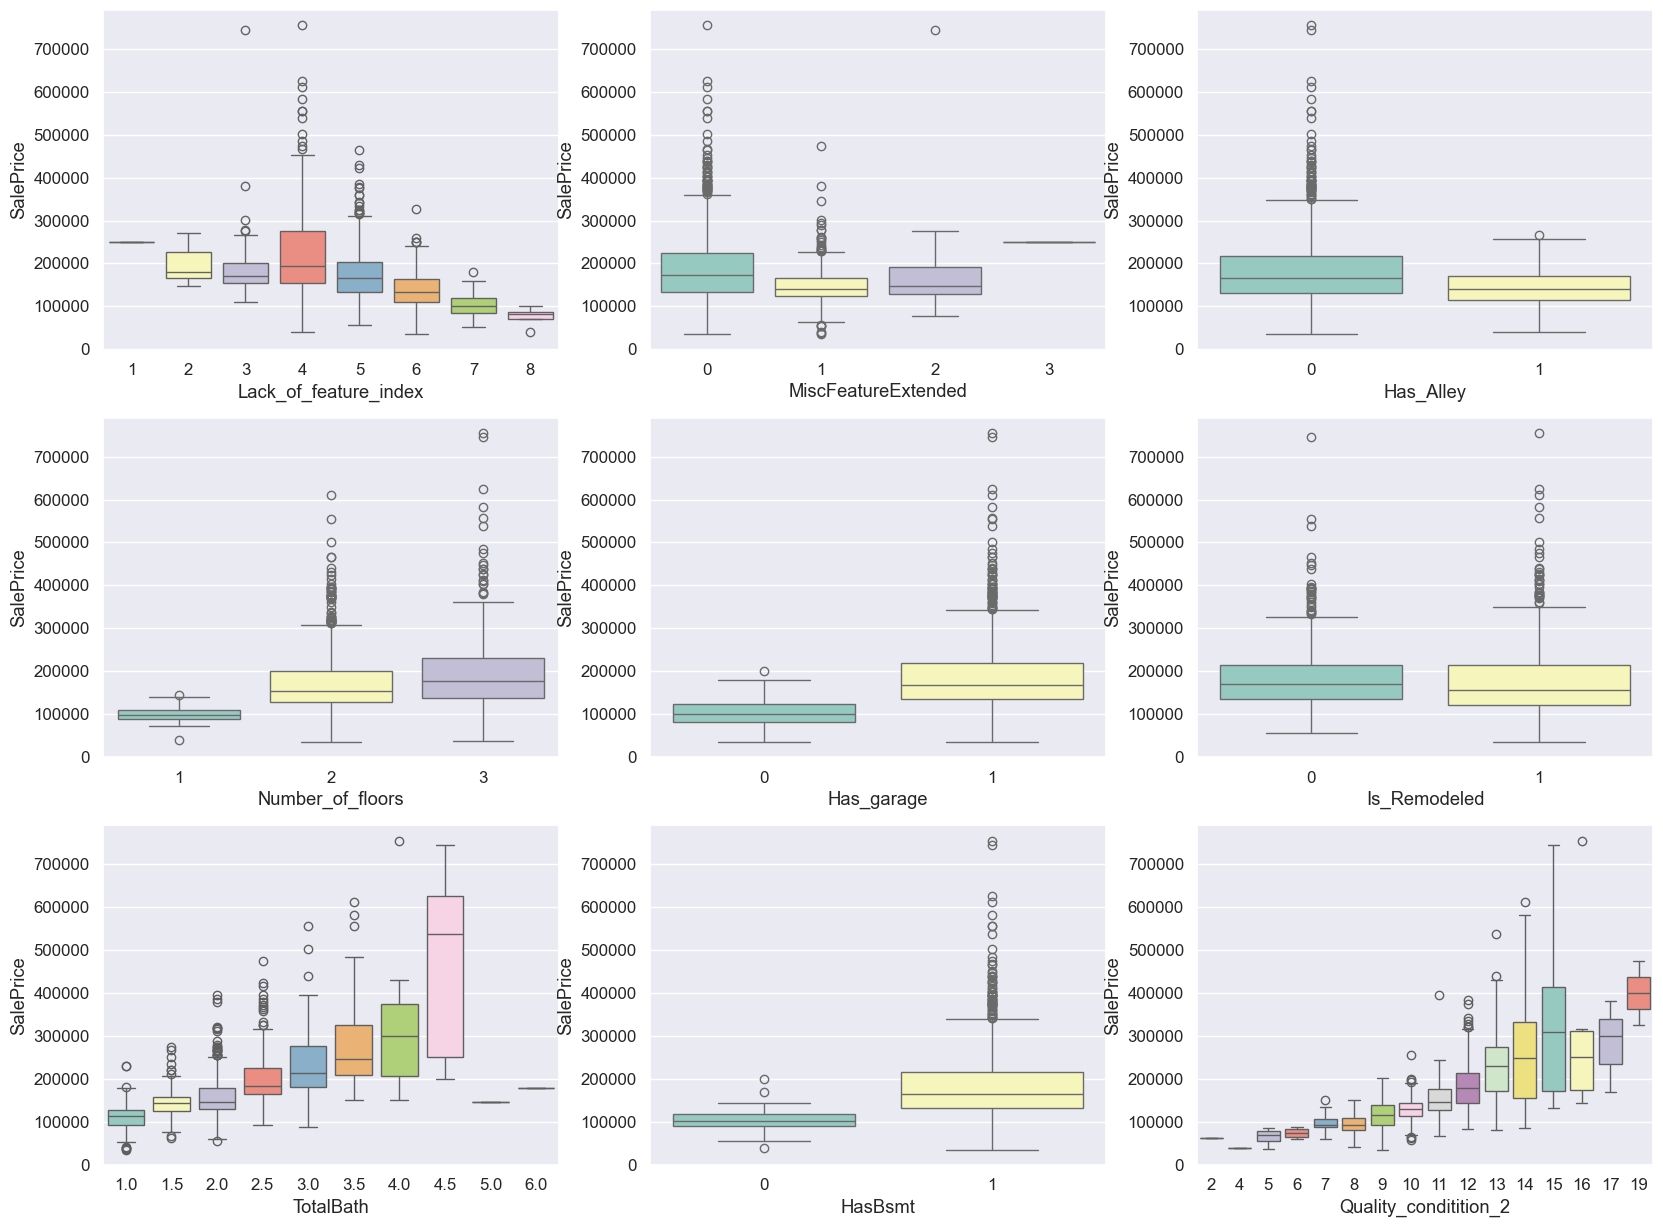

In [226]:
fig, ax = plt.subplots(3, 3, figsize=(20, 15))
for var, subplot in zip(new_discrete_features, ax.flatten()):
    sns.boxplot(x=var, y='SalePrice',  data=train_df, ax=subplot, palette='Set3')

In [227]:
### Update feature lists for bookkeeping
categorical_features = [feature for feature in train_df.columns if
                    train_df[feature].dtype == "object"]


ordinal_features = [ 'LotShape','Utilities','LandSlope','ExterQual','ExterCond','BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1',
                    'BsmtFinType2','HeatingQC','KitchenQual','Functional','FireplaceQu','GarageFinish','GarageQual',
                    'GarageCond','PavedDrive','PoolQC','Fence']




nominal_features = list(set(categorical_features) - set(ordinal_features)) 


numerical_features = list(set(train_df.columns) - set(categorical_features)) 

In [228]:
print(nominal_features)
print(numerical_features)

['Electrical', 'MasVnrType', 'Exterior1st', 'LandContour', 'Condition2', 'BldgType', 'Foundation', 'Neighborhood', 'CentralAir', 'RoofStyle', 'Exterior2nd', 'Street', 'SaleCondition', 'MSZoning', 'Condition1', 'GarageType', 'HouseStyle', 'Heating', 'RoofMatl', 'Alley', 'LotConfig', 'SaleType', 'MiscFeature']
['Has_Alley', 'Total_usable_area', 'Quality_conditition_2', 'MSSubClass', 'LotArea', 'BedroomAbvGr', 'House_Age', 'Is_Remodeled', 'Number_of_floors', '2ndFlrSF', 'Area_Qual_Cond_Indicator', 'OpenPorchSF', 'TotalBsmtSF', 'BsmtUnfSF', 'TotRmsAbvGrd', 'BsmtFinSF2', 'MiscFeatureExtended', 'MiscVal', 'Area_Quality_Indicator', 'House_Age2', 'HasBsmt', 'GarageArea', 'Total_Close_Live_Area', 'YrSold', 'SalePrice', 'PoolArea', 'MasVnrArea', 'OverallQual', 'LotFrontage', 'KitchenAbvGr', 'TotalBath', 'YearRemodAdd', 'BsmtFinSF1', '1stFlrSF', 'YearBuilt', 'HalfBath', 'Lack_of_feature_index', 'Outside_live_area', 'FullBath', 'LowQualFinSF', 'GarageCars', 'OverallCond', 'Quality_conditition', 'E

In [229]:
# Preprocessing for numerical data

numerical_transformer = Pipeline(steps=[
    
    ('imputer', SimpleImputer(strategy='constant', fill_value = 0))
])
# Preprocessing for categorical data
nominal_transformer = Pipeline(steps=[
    
    ('imputer', SimpleImputer(strategy='constant', fill_value = 'Do_not_have_this_feature')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [230]:
GarageQual_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0}
Fence_map = {'GdPrv': 4,'MnPrv': 3,'GdWo': 2, 'MnWw': 1,'NA': 0}
GarageFinish_map = {'Fin': 3, 'RFn': 2, 'Unf': 1, 'NA': 0}
KitchenQual_map = {'Ex': 4, 'Gd': 3, 'TA': 2, 'Fa': 1, 'Po': 0}
GarageCond_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0}
HeatingQC_map = {'Ex': 4, 'Gd': 3, 'TA': 2, 'Fa': 1, 'Po': 0}
ExterQual_map = {'Ex': 4, 'Gd': 3, 'TA': 2, 'Fa': 1, 'Po': 0}
BsmtCond_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0}
LandSlope_map = {'Gtl': 2, 'Mod': 1, 'Sev': 0}
ExterCond_map = {'Ex': 4, 'Gd': 3, 'TA': 2, 'Fa': 1, 'Po': 0}
BsmtExposure_map = {'Gd': 4, 'Av': 3, 'Mn': 2, 'No': 1, 'NA': 0}
PavedDrive_map = {'Y': 2, 'P': 1, 'N': 0}
BsmtQual_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0}
LotShape_map = {'Reg': 3, 'IR1': 2, 'IR2': 1, 'IR3': 0}
BsmtFinType2_map = {'GLQ': 6,'ALQ': 5,'BLQ': 4,'Rec': 3,'LwQ': 2,'Unf': 1, 'NA': 0}
BsmtFinType1_map = {'GLQ': 6,'ALQ': 5,'BLQ': 4,'Rec': 3,'LwQ': 2,'Unf': 1, 'NA': 0}
FireplaceQu_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0}
Utilities_map = {"AllPub":3, "NoSewr":2, "NoSeWa":1,  "ELO":0}
Functional_map = {'Typ': 7,'Min1': 6,'Min2': 5,'Mod': 4,'Maj1': 3,'Maj2': 2, 'Sev': 1 , 'Sal': 0}
PoolQC_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0}

In [231]:
globals()

{'__name__': '__main__',
 '__doc__': 'Automatically created module for IPython interactive environment',
 '__package__': None,
 '__loader__': None,
 '__spec__': None,
 '__builtin__': <module 'builtins' (built-in)>,
 '__builtins__': <module 'builtins' (built-in)>,
 '_ih': ['',
  'globals()',
  "fig, ax = plt.subplots(3, 3, figsize=(20, 20))\nfor var, subplot in zip(new_continuous_features, ax.flatten()):\n    sns.scatterplot(x=var, y='SalePrice',  data=train_df, ax=subplot)",
  '#basics\nimport numpy as np\nimport pandas as pd\nimport seaborn as sns\nimport matplotlib.pyplot as plt\nfrom sklearn.model_selection import train_test_split\nimport warnings\nwarnings.filterwarnings("ignore")\n\n\n#preprocessing\nfrom sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, PowerTransformer\nfrom sklearn.impute import SimpleImputer\nfrom sklearn.preprocessing import OneHotEncoder\nimport category_encoders as ce\nfrom sklearn.compose import TransformedTargetRegressor\nfrom sklea

In [232]:
ordinal_mapping = [{'col': col, 'mapping': globals()[col + '_map']} 
                    for col in ordinal_features]

In [233]:
ordinal_mapping

[{'col': 'LotShape', 'mapping': {'Reg': 3, 'IR1': 2, 'IR2': 1, 'IR3': 0}},
 {'col': 'Utilities',
  'mapping': {'AllPub': 3, 'NoSewr': 2, 'NoSeWa': 1, 'ELO': 0}},
 {'col': 'LandSlope', 'mapping': {'Gtl': 2, 'Mod': 1, 'Sev': 0}},
 {'col': 'ExterQual',
  'mapping': {'Ex': 4, 'Gd': 3, 'TA': 2, 'Fa': 1, 'Po': 0}},
 {'col': 'ExterCond',
  'mapping': {'Ex': 4, 'Gd': 3, 'TA': 2, 'Fa': 1, 'Po': 0}},
 {'col': 'BsmtQual',
  'mapping': {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0}},
 {'col': 'BsmtCond',
  'mapping': {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0}},
 {'col': 'BsmtExposure',
  'mapping': {'Gd': 4, 'Av': 3, 'Mn': 2, 'No': 1, 'NA': 0}},
 {'col': 'BsmtFinType1',
  'mapping': {'GLQ': 6,
   'ALQ': 5,
   'BLQ': 4,
   'Rec': 3,
   'LwQ': 2,
   'Unf': 1,
   'NA': 0}},
 {'col': 'BsmtFinType2',
  'mapping': {'GLQ': 6,
   'ALQ': 5,
   'BLQ': 4,
   'Rec': 3,
   'LwQ': 2,
   'Unf': 1,
   'NA': 0}},
 {'col': 'HeatingQC',
  'mapping': {'Ex': 4, 'Gd': 3, 'TA': 2, 'Fa': 1, 'Po': 0}},

In [234]:
ordinal_transformer = ce.OrdinalEncoder(mapping = ordinal_mapping)

In [235]:
ordinal_transformer = Pipeline(steps=[
    

    ('ordinal_encoder', ce.OrdinalEncoder(mapping = ordinal_mapping))
])

In [236]:
# Bundle preprocessing for tree-based algorithms
tree_preprocessor = ColumnTransformer(remainder=numerical_transformer,
    transformers=[

        
        ('nominal_transformer', nominal_transformer, nominal_features),
        ('ordinal_transformer', ordinal_transformer, ordinal_features),
        
            
    ])


set_config(display="diagram")
tree_preprocessor

ColumnTransformer(remainder=Pipeline(steps=[('imputer',
                                             SimpleImputer(fill_value=0,
                                                           strategy='constant'))]),
                  transformers=[('nominal_transformer',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value='Do_not_have_this_feature',
                                                                strategy='constant')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Electrical', 'MasVnrType', 'Exterior1st',
                                  'LandContour'...
dtype: int64},
                                                                          {'col': 'Fence',
                                                                           'data_type': dtype('O'),
                                                                           'mapping': GdPrv    4
MnPrv    3
GdWo     2
MnWw     1
NA       0
dtype: int64}]))]),
                                 ['LotShape', 'Utilities', 'LandSlope',
                                  'ExterQual', 'ExterCond', 'BsmtQual',
                                  'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
                                  'BsmtFinType2', 'HeatingQC', 'KitchenQual',
                                  'Functional', 'FireplaceQu', 'GarageFinish',
                                  'GarageQual', 'GarageCond', 'PavedDrive',
                                  'PoolQC', 'Fence'])])

In [237]:
# Preprocessing for numerical data
numerical_transformer2 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value = 0)),
    ('Scaller', StandardScaler()),    
     
    
])

# Preprocessing for categorical data
categorical_transformer = Pipeline(steps=[
    
    ('imputer', SimpleImputer(strategy='constant', fill_value = 'Do_not_have_this_feature')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [238]:
skew_features = train_df.select_dtypes(exclude=['object']).skew().sort_values(ascending=False)
skew_features = pd.DataFrame({'Skew' : skew_features})
skew_features.style.background_gradient('rocket')

,Skew
MiscVal,24.455241
PoolArea,15.926839
LotArea,12.628557
3SsnPorch,10.282620
LowQualFinSF,9.249359
KitchenAbvGr,4.518137
BsmtFinSF2,4.245246
ScreenPorch,4.112351
BsmtHalfBath,4.093529
Has_Alley,3.639899


In [239]:
#Kept limited with continuous features
skewed_features = [
'MiscVal',  'PoolArea', 'LotArea', '3SsnPorch', 'LowQualFinSF', 'BsmtFinSF2', 'ScreenPorch',
 'EnclosedPorch','Lot_occupation','MasVnrArea','OpenPorchSF',
    'Area_Qual_Cond_Indicator','LotFrontage','WoodDeckSF','Area_Quality_Indicator','Outside_live_area']

In [240]:
skewness_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value = 0)),
    ('PowerTransformer', PowerTransformer( method='yeo-johnson', standardize=True)),      
])

In [241]:
# Bundle preprocessing for linear algorithms and SVR
linear_preprocessor = ColumnTransformer(remainder=numerical_transformer2,
    transformers=[
        ('skewness_transformer', skewness_transformer, skewed_features),
        ('nominal_transformer', nominal_transformer, nominal_features),
        ('ordinal_transformer', ordinal_transformer, ordinal_features),
    ])

linear_preprocessor

ColumnTransformer(remainder=Pipeline(steps=[('imputer',
                                             SimpleImputer(fill_value=0,
                                                           strategy='constant')),
                                            ('Scaller', StandardScaler())]),
                  transformers=[('skewness_transformer',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value=0,
                                                                strategy='constant')),
                                                 ('PowerTransformer',
                                                  PowerTransformer())]),
                                 ['MiscVal', 'PoolArea', 'LotArea', '3SsnPorch',
                                  'LowQualFinSF',...
dtype: int64},
                                                                          {'col': 'Fence',
                                                                           'data_type': dtype('O'),
                                                                           'mapping': GdPrv    4
MnPrv    3
GdWo     2
MnWw     1
NA       0
dtype: int64}]))]),
                                 ['LotShape', 'Utilities', 'LandSlope',
                                  'ExterQual', 'ExterCond', 'BsmtQual',
                                  'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
                                  'BsmtFinType2', 'HeatingQC', 'KitchenQual',
                                  'Functional', 'FireplaceQu', 'GarageFinish',
                                  'GarageQual', 'GarageCond', 'PavedDrive',
                                  'PoolQC', 'Fence'])])

In [242]:
class FeatureCreator1(BaseEstimator, TransformerMixin):
    def __init__(self, add_attributes=True):
        self.add_attributes = add_attributes

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        if self.add_attributes:
            X_copy = X.copy()
            X_copy["Lack_of_feature_index"] = X_copy[["Street", "Alley", "MasVnrType", "GarageType", "MiscFeature",  'BsmtQual',
                                              'FireplaceQu','PoolQC','Fence']].isnull().sum(axis=1) + (X_copy["MasVnrType"] == 'None')+ (X_copy["CentralAir"] == 'No')
            X_copy["MiscFeatureExtended"] = (X_copy["PoolQC"].notnull()*1 + X_copy["MiscFeature"].notnull()*1+ X_copy["Fence"].notnull()*1).astype('int64')
            X_copy["Has_Alley"] = X_copy["Alley"].notnull().astype('int64')
            X_copy["Lot_occupation"] = X_copy["GrLivArea"]  / X_copy["LotArea"]
            X_copy["Number_of_floors"] = (X_copy["TotalBsmtSF"] != 0).astype('int64') + (X_copy["1stFlrSF"] != 0).astype('int64') + (X_copy["2ndFlrSF"] != 0).astype('int64')
            X_copy['Total_Close_Live_Area'] = X_copy['GrLivArea'] + X_copy['TotalBsmtSF'] 
            X_copy['Outside_live_area'] =  X_copy['WoodDeckSF'] + X_copy['OpenPorchSF'] + X_copy['EnclosedPorch']+ X_copy['3SsnPorch'] + X_copy['ScreenPorch']
            X_copy['Total_usable_area'] = X_copy['Total_Close_Live_Area'] + X_copy['Outside_live_area']
            X_copy['Area_Quality_Indicator'] = X_copy['Total_usable_area'] * X_copy['OverallQual']
            X_copy['Area_Qual_Cond_Indicator'] = X_copy['Total_usable_area'] * X_copy['OverallQual']* X_copy['OverallCond']
            X_copy['TotalBath'] = (X_copy['FullBath'] + (0.5 * X_copy['HalfBath']) + X_copy['BsmtFullBath'] + (0.5 * X_copy['BsmtHalfBath']))
            X_copy["Has_garage"] = X_copy["GarageYrBlt"].notnull().astype('int64')
            X_copy['House_Age'] = X_copy['YrSold'] - X_copy['YearBuilt']
            X_copy["Is_Remodeled"] = (X_copy["YearBuilt"] != X_copy["YearRemodAdd"]).astype('int64')
            X_copy['HasBsmt'] = X_copy['BsmtQual'].notnull().astype('int64')
            X_copy['Quality_conditition'] = X_copy['OverallQual']* X_copy['OverallCond']
            X_copy['Quality_conditition_2'] = X_copy['OverallQual'] + X_copy['OverallCond']
            X_copy['House_Age2'] = X_copy['YrSold'] - X_copy['YearRemodAdd']
            X_copy['Quality_conditition'] = X_copy['OverallQual']* X_copy['OverallCond']
            X_copy['Quality_conditition_2'] = X_copy['OverallQual'] + X_copy['OverallCond']
            X_copy['House_Age2'] = X_copy['YrSold'] - X_copy['YearRemodAdd']
            return X_copy
        else:
            return X_copy

In [243]:
Creator1 = FeatureCreator1(add_attributes = True)

In [244]:
pipe_xgb = Pipeline(steps=[
    ('Creator1', Creator1),
    ('tree_preprocessor', tree_preprocessor),
    ('regressor1', XGBRegressor(random_state =1)),
])
pipe_xgb

AttributeError: 'super' object has no attribute '__sklearn_tags__'

AttributeError: 'super' object has no attribute '__sklearn_tags__'

Pipeline(steps=[('Creator1', FeatureCreator1()),
                ('tree_preprocessor',
                 ColumnTransformer(remainder=Pipeline(steps=[('imputer',
                                                              SimpleImputer(fill_value=0,
                                                                            strategy='constant'))]),
                                   transformers=[('nominal_transformer',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Do_not_have_this_feature',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown...
                              feature_types=None, gamma=None, grow_policy=None,
                  

In [245]:
pipe_Lasso = Pipeline(steps=[
    ('Creator1', Creator1),
    ('linear_preprocessor', linear_preprocessor),
    ('regressor2', Lasso()),
])

TargetTransformedLasso = TransformedTargetRegressor(regressor=pipe_Lasso, func=np.log1p, inverse_func=np.expm1)
TargetTransformedLasso

TransformedTargetRegressor(func=<ufunc 'log1p'>, inverse_func=<ufunc 'expm1'>,
                           regressor=Pipeline(steps=[('Creator1',
                                                      FeatureCreator1()),
                                                     ('linear_preprocessor',
                                                      ColumnTransformer(remainder=Pipeline(steps=[('imputer',
                                                                                                   SimpleImputer(fill_value=0,
                                                                                                                 strategy='constant')),
                                                                                                  ('Scaller',
                                                                                                   StandardScaler())]),
                                                                        transformers=[('skewness_transformer',
                                                                                       Pipeline(steps=[('impu...
                                                                                                                                 'data_type': dtype('O'),
                                                                                                                                 'mapping': GdPrv    4
MnPrv    3
GdWo     2
MnWw     1
NA       0
dtype: int64}]))]),
                                                                                       ['LotShape',
                                                                                        'Utilities',
                                                                                        'LandSlope',
                                                                                        'ExterQual',
                                                                                        'ExterCond',
                                                                                        'BsmtQual',
                                                                                        'BsmtCond',
                                                                                        'BsmtExposure',
                                                                                        'BsmtFinType1',
                                                                                        'BsmtFinType2',
                                                                                        'HeatingQC',
                                                                                        'KitchenQual',
                                                                                        'Functional',
                                                                                        'FireplaceQu',
                                                                                        'GarageFinish',
                                                                                        'GarageQual',
                                                                                        'GarageCond',
                                                                                        'PavedDrive',
                                                                                        'PoolQC',
                                                                                        'Fence'])])),
                                                     ('regressor2', Lasso())]))